In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

pd.options.mode.chained_assignment = None # This tells pandas to stop showing warnings

In [ ]:
#Create dataframe
df = pd.read_csv('/content/drive/MyDrive/Big Data_Coursework/data.csv', encoding = "unicode_escape")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [ ]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [ ]:
df.shape

(541909, 8)

# **Cleaning the data.**

In [ ]:
df.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


In [ ]:
df.duplicated().sum()

np.int64(5268)

In [ ]:
df = df.drop_duplicates().reset_index(drop=True).copy()

In [ ]:
df_copy = df.copy()
df_copy['Description'] = df_copy['Description'].fillna("Unknown")
df_copy['CustomerID'] = df_copy['CustomerID'].fillna(1)
df_copy.isna().sum()

,0
InvoiceNo,0
StockCode,0
Description,0
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,0
Country,0


In [ ]:
df = df_copy.copy()

In [ ]:
df.dtypes

,0
InvoiceNo,object
StockCode,object
Description,object
Quantity,int64
InvoiceDate,object
UnitPrice,float64
CustomerID,float64
Country,object


In [ ]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['CustomerID'] = df['CustomerID'].astype('int')

In [ ]:
df.loc[df['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
297646,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,1,United Kingdom
297647,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,1,United Kingdom


In [ ]:
df.loc[df['StockCode'] == 'B']

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
297645,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,1,United Kingdom
297646,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,1,United Kingdom
297647,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,1,United Kingdom


In [ ]:
df = df.loc[df['StockCode'] != 'B']
#deleting all "Adjust bad debt" rows

In [ ]:
df.loc[df['Quantity'] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom


In [ ]:
df = df.loc[df['Quantity'] > 0]
#A quantity with a value < 0 may be the result of a product return or a "Buy 1, get 1 free"
#discount.

In [ ]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,526051.000000,526051,526051.000000,526051.000000
mean,10.730929,2011-07-04 13:30:20.477063680,3.892797,11413.562546
min,1.000000,2010-12-01 08:26:00,0.000000,1.000000
25%,1.000000,2011-03-28 11:36:00,1.250000,1.000000
50%,4.000000,2011-07-19 17:17:00,2.080000,14334.000000
75%,11.000000,2011-10-19 11:13:00,4.130000,16242.000000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000
std,157.592285,NaN,32.670802,6812.229429


<Axes: xlabel='Quantity', ylabel='UnitPrice'>

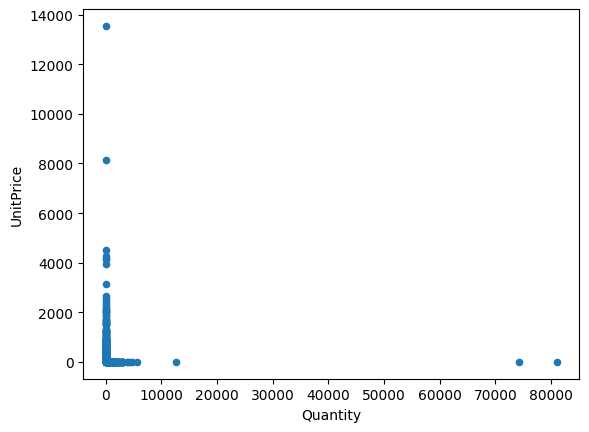

In [ ]:
df.plot(kind='scatter', x='Quantity', y='UnitPrice')

This scatter plot shows quantity bought versus unit price. Most purchases cluster on the left with small quantities at various prices. Two outliers appear far right, representing bulk orders of 70,000-80,000 units at low prices. The highest unit prices (around $8,000-$13,000) occur only with small quantities, suggesting premium items bought individually.

In [ ]:
#the 4 points at the end of x and y axis are outliers

df[df['UnitPrice'] > 6000]


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
14757,537632,AMAZONFEE,AMAZON FEE,1,2010-12-07 15:08:00,13541.33,1,United Kingdom
171873,551697,POST,POSTAGE,1,2011-05-03 13:46:00,8142.75,16029,United Kingdom


In [ ]:
df = df[df['UnitPrice'] < 6000]

In [ ]:
df[df['Quantity'] > 6000]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
61006,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,2011-01-18 10:01:00,1.04,12346,United Kingdom
497394,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,2011-11-25 15:57:00,0.00,13256,United Kingdom
535160,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446,United Kingdom


In [ ]:
#these values too, we can consider those values as outliers

In [ ]:
df = df[df['Quantity'] < 6000]

# **Analysis**

# **Understanding 'Country' feature.**

In [ ]:
df['TotalPrice'] = df['UnitPrice']*df['Quantity']

In [ ]:
IntensivityOfPurchases = df.groupby('Country').agg({'TotalPrice': 'count'}) \
    .sort_values(by = 'TotalPrice', ascending = False)
df['TotalPrice'] = df['UnitPrice'] * df['Quantity']
TotalMoneySpent = df.groupby('Country').agg({'TotalPrice': 'sum'}) \
    .sort_values(by = 'TotalPrice', ascending = False)

In [ ]:
IntensivityOfPurchases.head()

,TotalPrice
Country,
United Kingdom,481135
Germany,9027
France,8393
EIRE,7883
Spain,2480


In [ ]:
TotalMoneySpent.head()

,TotalPrice
Country,
United Kingdom,8723344.754
Netherlands,285446.340
EIRE,283140.520
Germany,228678.400
France,209625.370


<Axes: title={'center': 'Count of purchases'}, xlabel='Country'>

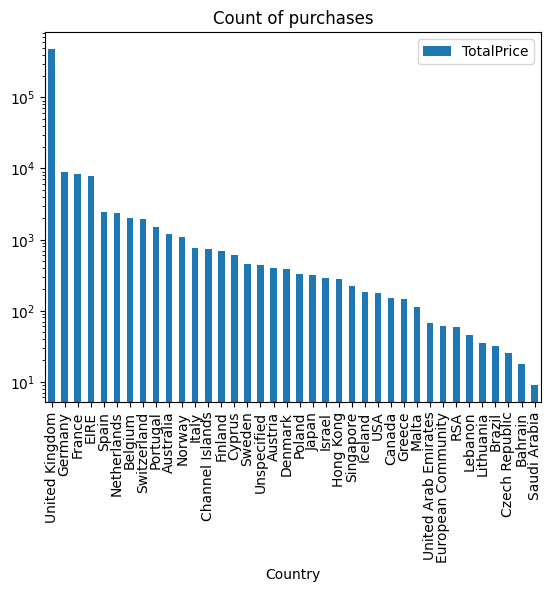

In [ ]:
IntensivityOfPurchases.plot(kind = 'bar', logy = True, title = 'Count of purchases')

This log-scale chart displays purchase counts by country. United Kingdom leads with the most purchases, then Germany, and France. The pattern mirrors spending data - countries with more purchases also spend more. The downward trend continues through smaller markets. The graph helps compare countries with very different purchase volumes.

<Axes: title={'center': 'Total money spent'}, xlabel='Country'>

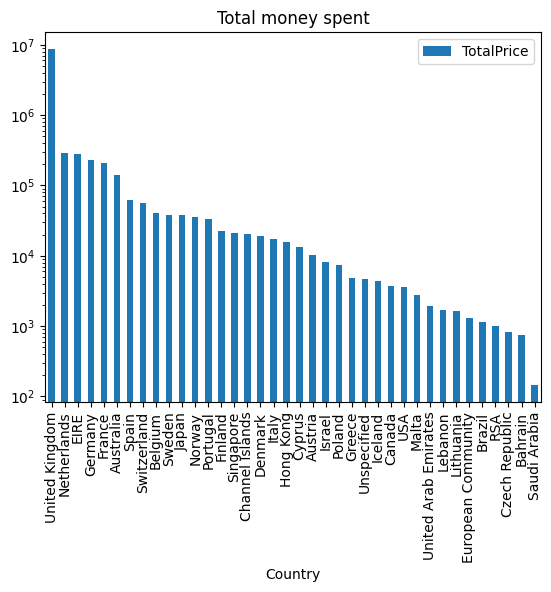

In [ ]:
TotalMoneySpent.plot(kind = 'bar', logy = True, title = 'Total money spent')

This log-scale bar chart shows total spending by country. United Kingdom dominates with the highest spending, followed by Ireland, Germany, and France. The spending drops steadily for other countries. Using a log scale makes it easier to see differences between both large and small spenders on one graph.

# **Understanding time feature**

In [ ]:
df['Hour']=df['InvoiceDate'].dt.hour
BestTimes = pd.DataFrame()
for country in df['Country'].unique():
    temp, res = pd.DataFrame(), pd.DataFrame()
    temp = df[df["Country"] == country]
    res = temp.groupby('Hour').count().reset_index()\
    .sort_values(by = 'InvoiceNo', ascending = False)\
    .head().reset_index(drop=True)
    BestTimes[country] = res['Hour']
BestTimes

#top 5 best sales hours in each country

,United Kingdom,France,Australia,Netherlands,Germany,Norway,EIRE,Switzerland,Spain,Poland,...,United Arab Emirates,Saudi Arabia,Czech Republic,Canada,Unspecified,Brazil,USA,European Community,Malta,RSA
0,15,10,13,11,13,13,10,10,13,10,...,17.0,10.0,8.0,10,16,10.0,16.0,10.0,8.0,12.0
1,12,13,12,10,12,14,14,12,14,13,...,12.0,NaN,10.0,9,12,NaN,10.0,12.0,14.0,NaN
2,13,12,10,12,14,16,12,9,11,11,...,13.0,NaN,NaN,13,15,NaN,12.0,16.0,9.0,NaN
3,14,11,9,15,15,9,13,15,9,12,...,NaN,NaN,NaN,11,13,NaN,NaN,NaN,NaN,NaN
4,16,14,15,14,10,8,9,14,15,8,...,NaN,NaN,NaN,12,14,NaN,NaN,NaN,NaN,NaN


# **Most popular products**

<Axes: xlabel='Description'>

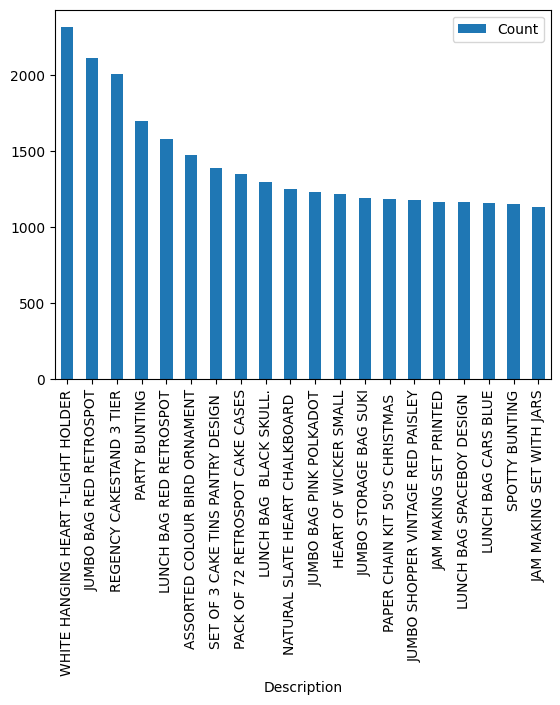

In [ ]:
ForProdPlot = df.groupby('Description').agg({'Description' : 'count'})
ForProdPlot.columns = ['Count']
ForProdPlot.sort_values(by = 'Count', ascending = False).head(20).plot(kind='bar')

This bar chart ranks product sales by item. White Hanging Heart T-Light Holder leads with the highest sales, followed by Jumbo Bag Red Retrospot. Sales gradually decrease for other products. Popular items include decorative holders, bags, and vintage-style products. The chart helps identify best-selling items, with decorative and gift items dominating the top positions.

In [ ]:
BestProducts = pd.DataFrame()
for country in df['Country'].unique():
    temp = df[df["Country"] == country]
    res = temp.groupby('Description').count().reset_index()\
    .sort_values(by = 'InvoiceNo', ascending = False)\
    .head(10).reset_index(drop=True)
    BestProducts[country] = res['Description']
BestProducts
#top 10 best selling products in each country

,United Kingdom,France,Australia,Netherlands,Germany,Norway,EIRE,Switzerland,Spain,Poland,...,United Arab Emirates,Saudi Arabia,Czech Republic,Canada,Unspecified,Brazil,USA,European Community,Malta,RSA
0,WHITE HANGING HEART T-LIGHT HOLDER,POSTAGE,SET OF 3 CAKE TINS PANTRY DESIGN,POSTAGE,POSTAGE,POSTAGE,CARRIAGE,POSTAGE,POSTAGE,LARGE CHINESE STYLE SCISSOR,...,SPACEBOY BABY GIFT SET,ASSORTED BOTTLE TOP MAGNETS,12 PENCILS SMALL TUBE RED RETROSPOT,COLOURING PENCILS BROWN TUBE,3 STRIPEY MICE FELTCRAFT,CLOCK MAGNET MUM'S KITCHEN,CARD DOLLY GIRL,POSTAGE,GRAND CHOCOLATECANDLE,4 TRADITIONAL SPINNING TOPS
1,JUMBO BAG RED RETROSPOT,RABBIT NIGHT LIGHT,RED TOADSTOOL LED NIGHT LIGHT,SPACEBOY LUNCH BOX,ROUND SNACK BOXES SET OF4 WOODLAND,SET OF 3 CAKE TINS PANTRY DESIGN,REGENCY CAKESTAND 3 TIER,PLASTERS IN TIN SPACEBOY,REGENCY CAKESTAND 3 TIER,SET OF 6 SPICE TINS PANTRY DESIGN,...,10 COLOUR SPACEBOY PEN,GLASS JAR DAISY FRESH COTTON WOOL,12 PENCILS SMALL TUBE SKULL,BUNDLE OF 3 ALPHABET EXERCISE BOOKS,ASSORTED COLOUR BIRD ORNAMENT,COOK WITH WINE METAL SIGN,PINK HAPPY BIRTHDAY BUNTING,BISCUIT TIN VINTAGE RED,POSTAGE,ALARM CLOCK BAKELIKE RED
2,REGENCY CAKESTAND 3 TIER,RED TOADSTOOL LED NIGHT LIGHT,LUNCH BAG RED RETROSPOT,ROUND SNACK BOXES SET OF4 WOODLAND,ROUND SNACK BOXES SET OF 4 FRUITS,REGENCY CAKESTAND 3 TIER,ROSES REGENCY TEACUP AND SAUCER,PLASTERS IN TIN WOODLAND ANIMALS,6 RIBBONS RUSTIC CHARM,POSTAGE,...,12 PENCILS TALL TUBE POSY,GLASS JAR MARMALADE,3 HOOK HANGER MAGIC GARDEN,BUNDLE OF 3 SCHOOL EXERCISE BOOKS,TRADITIONAL WOODEN SKIPPING ROPE,DOLLY GIRL LUNCH BOX,EMBROIDERED RIBBON REEL SUSIE,MEASURING TAPE BABUSHKA BLUE,CHRISTMAS PUDDING TRINKET POT,ASSORTED BOTTLE TOP MAGNETS
3,PARTY BUNTING,PLASTERS IN TIN WOODLAND ANIMALS,LUNCH BAG SPACEBOY DESIGN,DOLLY GIRL LUNCH BOX,PLASTERS IN TIN WOODLAND ANIMALS,CHILDS BREAKFAST SET DOLLY GIRL,WHITE HANGING HEART T-LIGHT HOLDER,ROUND SNACK BOXES SET OF4 WOODLAND,JAM MAKING SET WITH JARS,IVORY KITCHEN SCALES,...,36 FOIL STAR CAKE CASES,GLASS JAR PEACOCK BATH SALTS,ASSORTED COLOUR LIZARD SUCTION HOOK,60 CAKE CASES DOLLY GIRL DESIGN,SET OF 9 BLACK SKULL BALLOONS,DOORMAT AIRMAIL,SET/10 BLUE POLKADOT PARTY CANDLES,OFFICE MUG WARMER POLKADOT,TRIPLE PHOTO FRAME CORNICE,BAKING SET 9 PIECE RETROSPOT
4,LUNCH BAG RED RETROSPOT,PLASTERS IN TIN CIRCUS PARADE,ROSES REGENCY TEACUP AND SAUCER,ROUND SNACK BOXES SET OF 4 FRUITS,REGENCY CAKESTAND 3 TIER,SET OF TEA COFFEE SUGAR TINS PANTRY,VINTAGE SNAP CARDS,REGENCY CAKESTAND 3 TIER,SPACEBOY LUNCH BOX,RECIPE BOX PANTRY YELLOW DESIGN,...,6 RIBBONS EMPIRE,GOLD EAR MUFF HEADPHONES,BAKING MOULD HEART MILK CHOCOLATE,ABC TREASURE BOOK BOX,SET OF 60 I LOVE LONDON CAKE CASES,EDWARDIAN PARASOL BLACK,SET 12 COLOURING PENCILS DOILY,ROUND CAKE TIN VINTAGE RED,SET/3 VANILLA SCENTED CANDLE IN BOX,BELLE JARDINIERE CUSHION COVER
5,ASSORTED COLOUR BIRD ORNAMENT,ROUND SNACK BOXES SET OF4 WOODLAND,BAKING SET SPACEBOY DESIGN,SPACEBOY BIRTHDAY CARD,WOODLAND CHARLOTTE BAG,FAWN BLUE HOT WATER BOTTLE,JAM MAKING SET PRINTED,PLASTERS IN TIN CIRCUS PARADE,ASSORTED COLOUR BIRD ORNAMENT,PANTRY WASHING UP BRUSH,...,6 RIBBONS RUSTIC CHARM,HOMEMADE JAM SCENTED CANDLES,CHRISTMAS TABLE SILVER CANDLE SPIKE,AIRLINE BAG VINTAGE WORLD CHAMPION,SMALL HEART MEASURING SPOONS,EDWARDIAN PARASOL NATURAL,SET OF 12 FAIRY CAKE BAKING CASES,ROUND CAKE TIN VINTAGE GREEN,SET/3 ROSE CANDLE IN JEWELLED BOX,BIRDHOUSE GARDEN MARKER
6,SET OF 3 CAKE TINS PANTRY DESIGN,LUNCH BAG RED RETROSPOT,PARTY BUNTING,WOODLAND CHARLOTTE BAG,PLASTERS IN TIN CIRCUS PARADE,IVORY KITCHEN SCALES,GREEN REGENCY TEACUP AND SAUCER,CHILDRENS CUTLERY SPACEBOY,ROUND SNACK BOXES SET OF4 WOODLAND,STRAWBERRY CERAMIC TRINKET BOX,...,"AIRLINE LOUNGE,METAL SIGN",PLASTERS IN TIN CIRCUS PARADE,COLOUR GLASS T-LIGHT HOLDER HANGING,ALARM CLOCK BAKELIKE ORANGE,4 TRADITIONAL SPINNING TOPS,EDWARDIAN PARASOL PINK,SET OF 6 RIBBONS VINTAGE CHRISTMAS,OFFICE MUG WARMER CHOC+BLUE,SET/3 OCEAN SCENT CANDLE JEWEL BOX,CARD HOLDER LOVE BIRD SMALL
7,LUNCH BAG BLACK SKULL.,

# **Analysing customers**

In [ ]:
df_customers = df.loc[df['CustomerID'] != 1]
df_customers.groupby('CustomerID').agg({'TotalPrice':'sum'})\
.sort_values(by='TotalPrice', ascending=False).head(20)
#top 20 shoppers who spent the most money

,TotalPrice
CustomerID,
14646,280206.02
18102,259657.30
17450,194390.79
14911,143711.17
12415,124914.53
14156,117210.08
17511,91062.38
16029,72708.09
16684,66653.56


In [ ]:
len(df_customers['CustomerID'].unique())

4337

In [ ]:
df_frequency = df_customers.groupby('CustomerID').agg({'InvoiceDate':'count'}).reset_index()
df_frequency.rename(columns = {'InvoiceDate':  'OrdersCount'}, inplace = True )
df_frequency[df_frequency['OrdersCount'] == 1].sum()
#only 70 customer, from who has an CustomerID has puchased only once

,0
CustomerID,1116372
OrdersCount,70


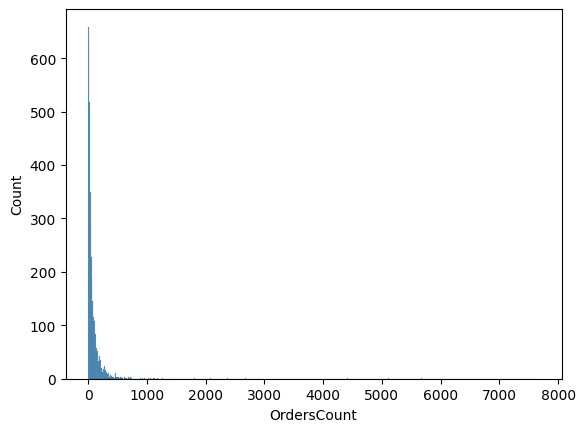

In [ ]:
sns.histplot(data=df_frequency['OrdersCount'])
plt.show()

This histogram displays order frequency distribution. The tall bar near zero shows that most customers place very few orders. The count drops dramatically as order numbers increase. No customers have more than about 1,000 orders. This pattern is typical for businesses where most customers buy occasionally while very few are frequent buyers.

In [ ]:
df_frequency[df_frequency['OrdersCount'] > 2000]
#shows highly active customers; customers who have ordered more than 2000 times

,CustomerID,OrdersCount
325,12748,4413
1288,14096,5111
1660,14606,2677
1688,14646,2080
1878,14911,5672
2175,15311,2366
4009,17841,7676


In [ ]:
df_aov = df_customers.groupby('CustomerID').agg({'TotalPrice':'mean'}).reset_index()
df_aov.rename(columns={'TotalPrice':'AOV'}, inplace=True)
df_aov


,CustomerID,AOV
0,12347,23.681319
1,12348,57.975484
2,12349,24.076027
3,12350,19.670588
4,12352,29.482824
...,...,...
4332,18280,18.060000
4333,18281,11.545714
4334,18282,14.837500
4335,18283,2.837074


In [ ]:
df_cust_metrics = df_aov.merge(df_frequency, on='CustomerID')
df_cust_metrics

,CustomerID,AOV,OrdersCount
0,12347,23.681319,182
1,12348,57.975484,31
2,12349,24.076027,73
3,12350,19.670588,17
4,12352,29.482824,85
...,...,...,...
4332,18280,18.060000,10
4333,18281,11.545714,7
4334,18282,14.837500,12
4335,18283,2.837074,721


<Axes: xlabel='OrdersCount', ylabel='AOV'>

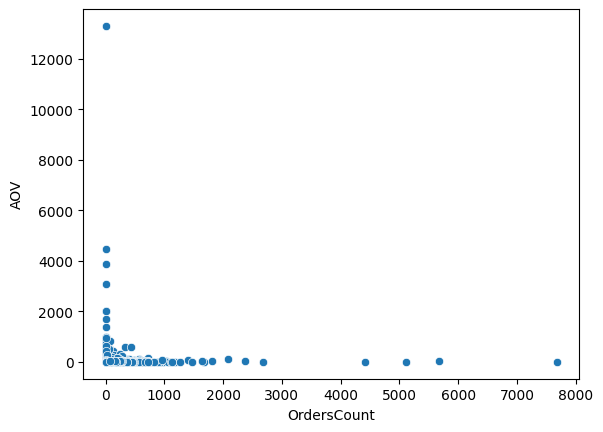

In [ ]:
sns.scatterplot(data=df_cust_metrics, x='OrdersCount', y='AOV')

This scatter plot shows customer spending patterns. Most customers cluster at the bottom-left, making few orders with low annual spending. One customer stands out at the top - they spend much more (around $13,000) despite ordering infrequently. The graph reveals that high-value customers don't necessarily order often.

In [ ]:
df_cust_metrics[df_cust_metrics['AOV'] > 12000]
#this customer with highest Average Order Value seems like outlier

,CustomerID,AOV,OrdersCount
2010,15098,13305.5,3


In [ ]:
df[df['CustomerID'] == 15098]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Hour
220815,556442,22502,PICNIC BASKET WICKER SMALL,60,2011-06-10 15:22:00,4.95,15098,United Kingdom,297.0,15
220825,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,2011-06-10 15:28:00,649.50,15098,United Kingdom,38970.0,15
220827,556446,22502,PICNIC BASKET WICKER 60 PIECES,1,2011-06-10 15:33:00,649.50,15098,United Kingdom,649.5,15


In [ ]:
purchases_length = df_customers.groupby('CustomerID').agg({'InvoiceDate':['min', 'max']}).reset_index()
purchases_length['diff']=(purchases_length['InvoiceDate']['max']-purchases_length['InvoiceDate'][max]) / np.timedelta64 ( 1 , 'D')
purchases_length=purchases_length.sort_values(by='diff', ascending=False).copy()
purchases_length['diff']=round(purchases_length['diff']).astype(int)
purchases_length = purchases_length.drop('InvoiceDate', axis=1).reset_index(drop=True).copy()
purchases_length

<ipython-input-44-fb7213e33bba>:5: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  purchases_length = purchases_length.drop('InvoiceDate', axis=1).reset_index(drop=True).copy()


,CustomerID,diff
,,
0,15311,373
1,12748,373
2,12662,373
3,12433,373
4,13777,373
...,...,...
4332,12902,0
4333,16769,0
4334,16773,0


In [ ]:
purchases_length=pd.DataFrame(purchases_length)
purchases_length

,CustomerID,diff
,,
0,15311,373
1,12748,373
2,12662,373
3,12433,373
4,13777,373
...,...,...
4332,12902,0
4333,16769,0
4334,16773,0


In [ ]:
purchases_length[purchases_length['diff'] == 0].count()
#1548 customer made purchases during first month only

,,0
CustomerID,,1548
diff,,1548


# **Egineering customers custering model**

## Features engineering

In [ ]:
df['Description'].nunique()

4076

From my point of view it is useless to somehow encode those 4076 values, so i'll just drop this column.

In [ ]:
df.drop(['Description'], axis=1, inplace=True)
df.drop(['InvoiceNo'], axis=1, inplace=True)

Splitting Date to Year, Month, ect.

In [ ]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Day'] = df['InvoiceDate'].dt.day
df['DayOfWeek'] = df['InvoiceDate'].dt.dayofweek
df['Hour'] = df['InvoiceDate'].dt.hour

In [ ]:
df.drop(['StockCode'], inplace=True, axis=1)

In [ ]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

In [ ]:
df

,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Hour,Year,Month,Day,DayOfWeek
0,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,8,2010,12,1,2
1,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,8,2010,12,1,2
2,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,8,2010,12,1,2
3,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,8,2010,12,1,2
4,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,8,2010,12,1,2
...,...,...,...,...,...,...,...,...,...,...,...
536636,12,2011-12-09 12:50:00,0.85,12680,France,10.20,12,2011,12,9,4
536637,6,2011-12-09 12:50:00,2.10,12680,France,12.60,12,2011,12,9,4
536638,4,2011-12-09 12:50:00,4.15,12680,France,16.60,12,2011,12,9,4
536639,4,2011-12-09 12:50:00,4.15,12680,France,16.60,12,2011,12,9,4


In [ ]:
from collections import Counter


agg_functions = {'Quantity': 'mean', 'UnitPrice': 'mean', 'TotalPrice': ['mean', 'sum']}

X = pd.DataFrame(df.groupby('CustomerID').agg(agg_functions).reset_index())

In [ ]:
X

CustomerID   Quantity UnitPrice TotalPrice            
                      mean      mean       mean         sum
0             1   3.593881  6.051300  12.978731  1730298.52
1         12347  13.505495  2.644011  23.681319     4310.00
2         12348  75.516129  5.764839  57.975484     1797.24
3         12349   8.643836  8.289041  24.076027     1757.55
4         12350  11.588235  3.841176  19.670588      334.40
...         ...        ...       ...        ...         ...
4333      18280   4.500000  4.765000  18.060000      180.60
4334      18281   7.714286  5.622857  11.545714       80.82
4335      18282   8.583333  5.199167  14.837500      178.05
4336      18283   1.882108  1.628752   2.837074     2045.53
4337      18287  22.657143  1.493571  26.246857     1837.28

[4338 rows x 5 columns]

In [ ]:
X.columns = ['customer_id', 'quantity_mean', 'unitprice_mean', 'aov', 'total_money_spent']

cust_id = X['customer_id']

X.drop(['customer_id'], axis=1, inplace=True)

In [ ]:
X.head()

,quantity_mean,unitprice_mean,aov,total_money_spent
0,3.593881,6.051300,12.978731,1730298.52
1,13.505495,2.644011,23.681319,4310.00
2,75.516129,5.764839,57.975484,1797.24
3,8.643836,8.289041,24.076027,1757.55
4,11.588235,3.841176,19.670588,334.40


**Choosing number of clusters we will use**

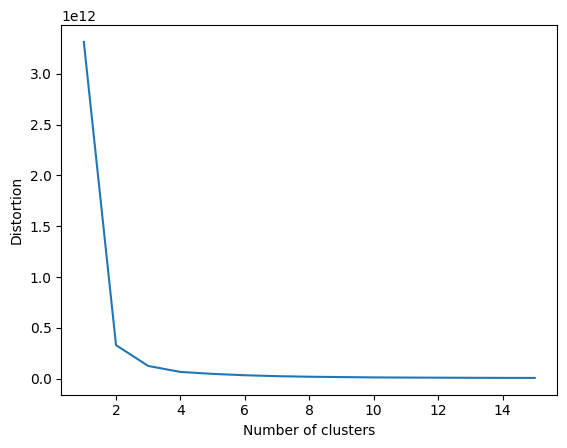

In [ ]:
from sklearn.cluster import KMeans

dist = []

for i in range(1, 16):
    km = KMeans(n_clusters=i,
               init='k-means++',
               n_init=10)
    km.fit(X)
    dist.append(km.inertia_)

plt.plot(range(1, 16), dist)
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.show()



**As we can see, we should choose 3 as n_clusters.**

This elbow graph helps find the best number of groups for clustering. The line drops sharply at first, then flattens out. The "elbow" or bend happens around 2-3 clusters, which suggests that's the ideal number of groups for this data. After 3, adding more clusters doesn't improve the results much.

In [ ]:
km = KMeans(n_clusters=3,
            init='k-means++',
            n_init=10)
km.fit(X)

KMeans(n_clusters=3, n_init=10)

In [ ]:
customer_clustering = X
customer_clustering['cluster_label'] = km.labels_
customer_clustering['customer_id'] = cust_id

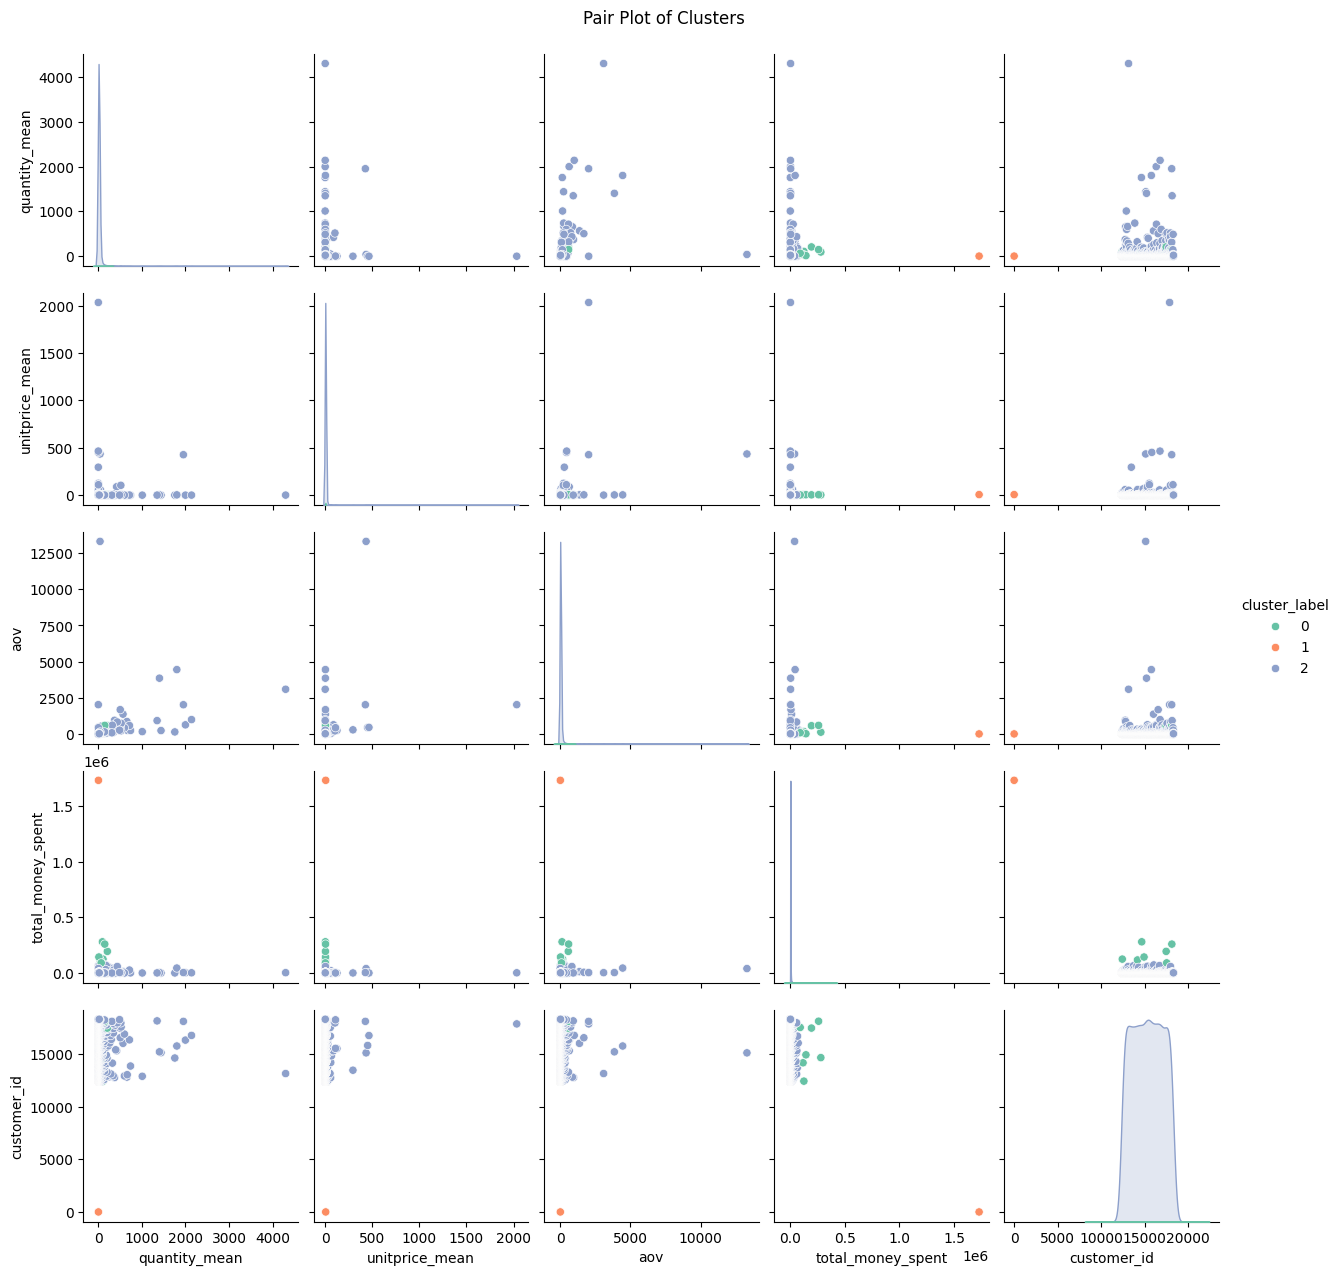

In [ ]:
# sns.pairplot(customer_clustering, hue='cluster_label')
import seaborn as sns

sns.pairplot(customer_clustering, hue='cluster_label', palette='Set2')
plt.suptitle("Pair Plot of Clusters", y=1.02)
plt.show()


This pair plot shows how different shopping variables relate to each other. The data is split into 3 groups (green, orange, purple). Green dots form the main group, showing typical shoppers. Orange dots (group 1) appear as single outliers in most plots, indicating unusual buying patterns. Purple dots (group 2) are scattered between normal and extreme values. Most relationships show that when one value increases, the other stays similar, except for quantity vs total_money_spent which shows a clear upward trend.

Cluster Counts:
 0    117803
1    367053
2     41190
Name: count, dtype: int64


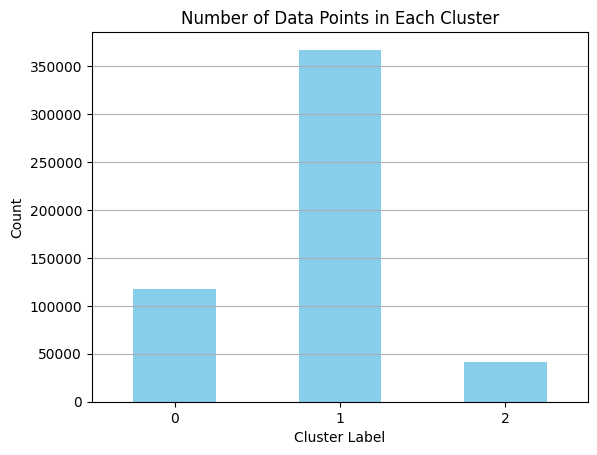

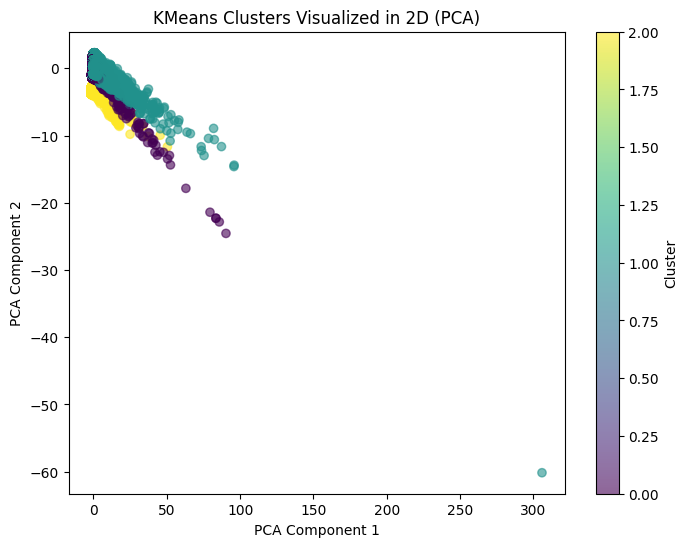

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

numeric_df = df.select_dtypes(include=np.number)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)

# Step 3: KMeans Clustering
kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
kmeans.fit(X_scaled)
labels = kmeans.labels_

cluster_counts = pd.Series(labels).value_counts().sort_index()
print("Cluster Counts:\n", cluster_counts)

cluster_counts.plot(kind='bar', color='skyblue')
plt.title("Number of Data Points in Each Cluster")
plt.xlabel("Cluster Label")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.6)
plt.title("KMeans Clusters Visualized in 2D (PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.show()


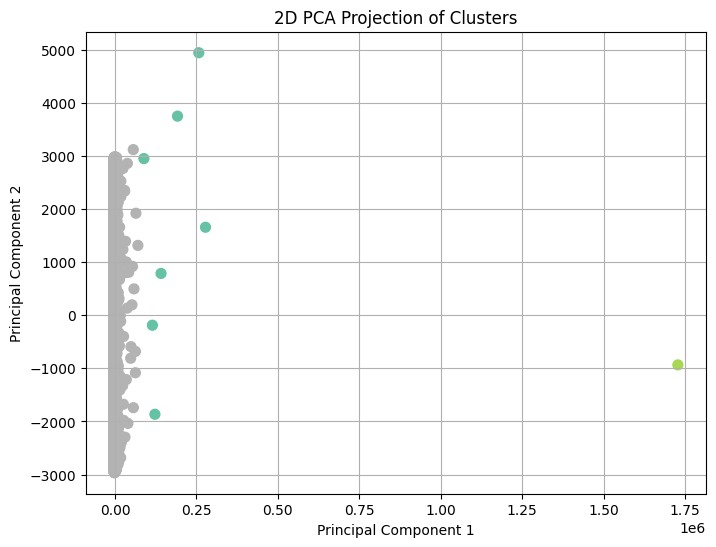

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=km.labels_, cmap='Set2', s=50)
plt.title("2D PCA Projection of Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True)
plt.show()


This graph shows data grouped by color using PCA. Most dots cluster on the left side, meaning they're similar. Two dots stand alone - green at top and light light green on right - showing they're very different from the others. The axes show the main differences in the data.

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# After fitting KMeans
labels = km.labels_

# Silhouette Score (higher is better)
silhouette = silhouette_score(X, labels)

# Davies-Bouldin Index (lower is better)
davies_bouldin = davies_bouldin_score(X, labels)

# Calinski-Harabasz Index (higher is better)
calinski_harabasz = calinski_harabasz_score(X, labels)

print(f"Silhouette Score: {silhouette:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin:.4f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz:.4f}")


Silhouette Score: 0.9772
Davies-Bouldin Index: 0.2625
Calinski-Harabasz Index: 55954.7745


#Seasonal Forecasting

In [ ]:
!pip install prophet


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpzqzvlxqb/wzmxbvtt.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpzqzvlxqb/ua1qmb10.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=59955', 'data', 'file=/tmp/tmpzqzvlxqb/wzmxbvtt.json', 'init=/tmp/tmpzqzvlxqb/ua1qmb10.json', 'output', 'file=/tmp/tmpzqzvlxqb/prophet_modelgqzeucmt/prophet_model-20250514055834.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
05:58:34 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
05:58:34 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


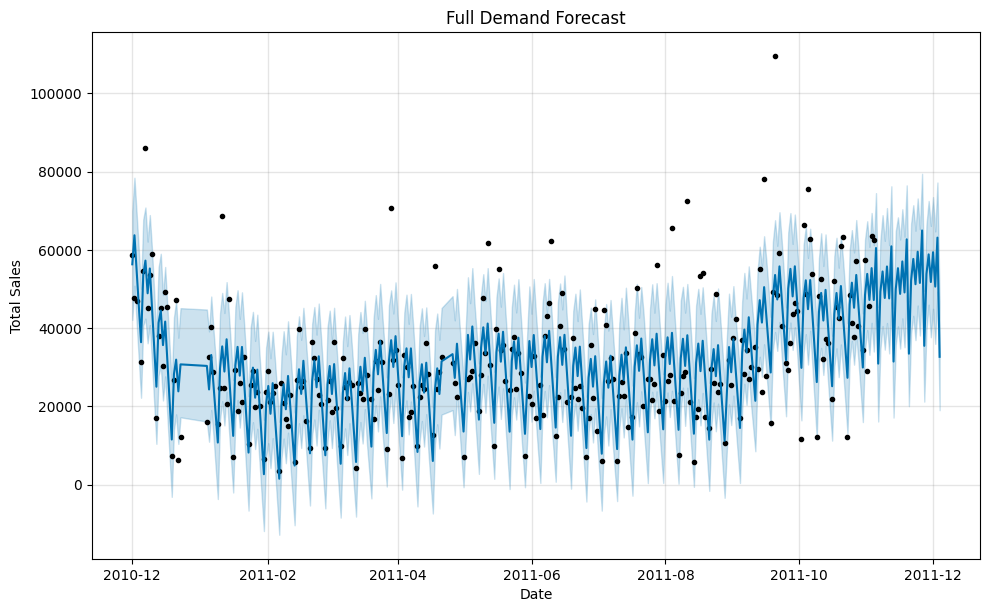

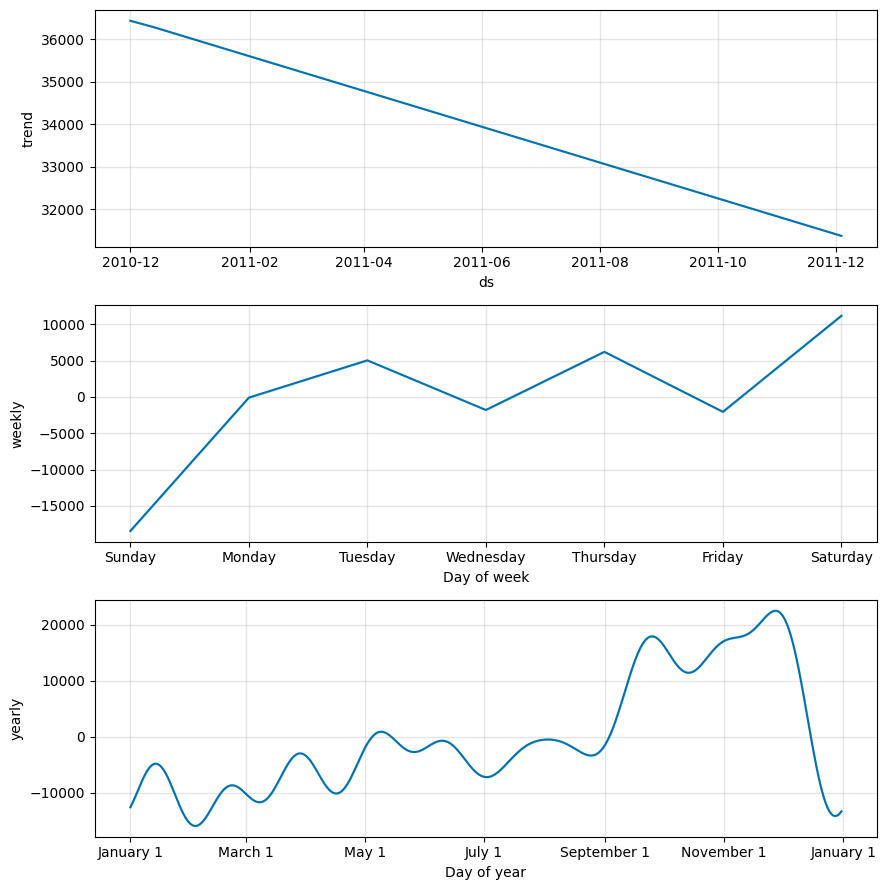

🔍 Prophet Performance on Last 30 Days:
MAE: 11893.92
MSE: 326501134.03
RMSE: 18069.34
MAPE: 19.64%


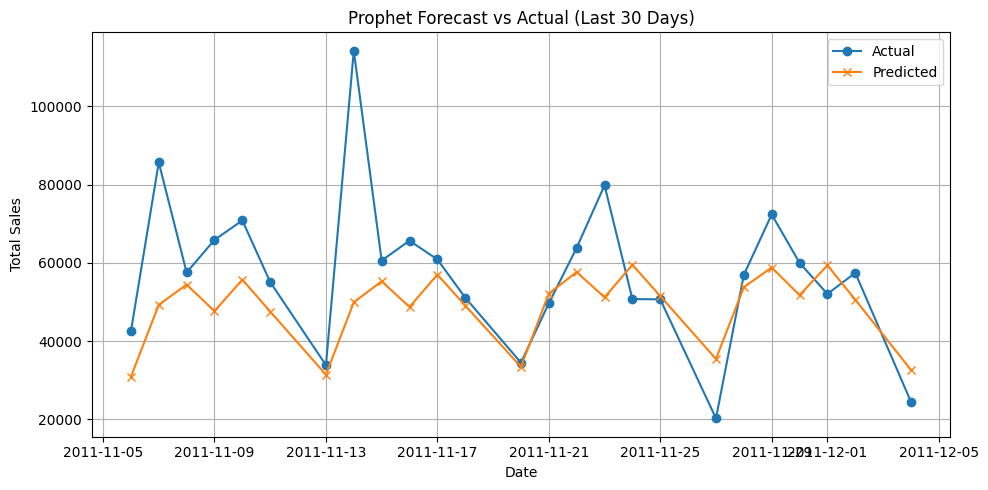

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Aggregate daily sales
daily_sales = df.groupby(df['InvoiceDate'].dt.date)['TotalPrice'].sum().reset_index()

# Rename columns for Prophet
daily_sales.columns = ['ds', 'y']
daily_sales['ds'] = pd.to_datetime(daily_sales['ds'])

# Split into training and test data (last 30 days as test)
train = daily_sales[:-30]
test = daily_sales[-30:]

# Fit the Prophet model
model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
model.fit(train)

# Make future predictions
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# Plot the full forecast
model.plot(forecast)
plt.title('Full Demand Forecast')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.grid(True)
plt.show()

# Plot the forecast components
model.plot_components(forecast)
plt.show()

#Evaluate the forecast (only on the last 30 days)
forecast_test = forecast[forecast['ds'].isin(test['ds'])]

# Merge actual and predicted values
merged = pd.merge(test, forecast_test[['ds', 'yhat']], on='ds', how='inner')

# Calculate performance metrics
mae = mean_absolute_error(merged['y'], merged['yhat'])
mse = mean_squared_error(merged['y'], merged['yhat'])
rmse = np.sqrt(mse)
mape = np.mean(np.abs((merged['y'] - merged['yhat']) / merged['y'])) * 100

print("🔍 Prophet Performance on Last 30 Days:")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

#  Plot actual vs predicted values for last 30 days
plt.figure(figsize=(10, 5))
plt.plot(merged['ds'], merged['y'], label='Actual', marker='o')
plt.plot(merged['ds'], merged['yhat'], label='Predicted', marker='x')
plt.title("Prophet Forecast vs Actual (Last 30 Days)")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpzqzvlxqb/uxjgz_hq.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpzqzvlxqb/4w6irfnk.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=79168', 'data', 'file=/tmp/tmpzqzvlxqb/uxjgz_hq.json', 'init=/tmp/tmpzqzvlxqb/4w6irfnk.json', 'output', 'file=/tmp/tmpzqzvlxqb/prophet_model3oc7rqa3/prophet_model-20250514060300.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
06:03:00 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
06:03:00 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing
<ipython-input-106-b55d05e35aa0>:77: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_la

📊 Final Prophet Model (Outlier-Capped + Regressors):
MAE: 11028.09
MSE: 203886525.86
RMSE: 14278.88
MAPE: 18.69%


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


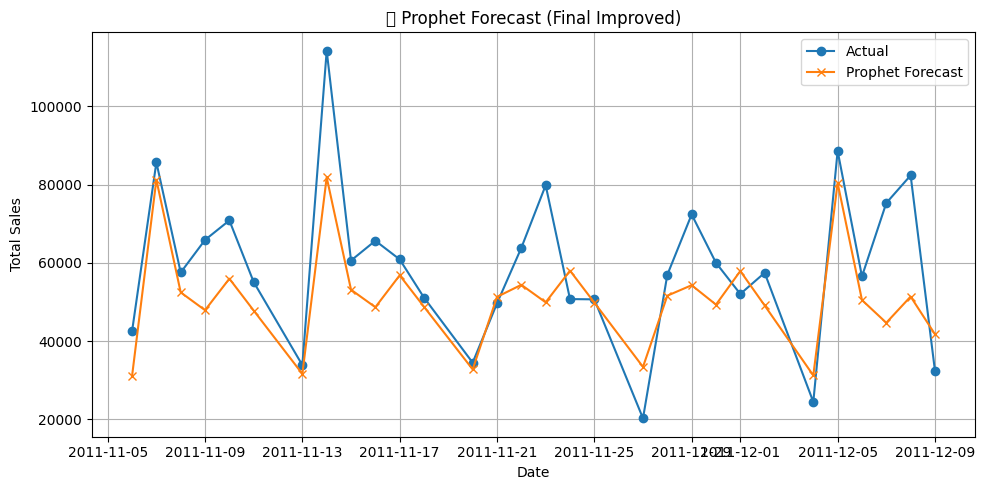

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load & Aggregate
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
daily_sales = df.groupby(df['InvoiceDate'].dt.date)['TotalPrice'].sum().reset_index()
daily_sales.columns = ['ds', 'y']
daily_sales['ds'] = pd.to_datetime(daily_sales['ds'])

#  Cap Outliers
q1 = daily_sales['y'].quantile(0.25)
q3 = daily_sales['y'].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
daily_sales['y_capped'] = np.where(daily_sales['y'] > upper_bound, upper_bound, daily_sales['y'])

# : Add Custom Regressors
daily_sales['day_of_week'] = daily_sales['ds'].dt.weekday
daily_sales['is_weekend'] = daily_sales['day_of_week'].isin([5, 6]).astype(int)
daily_sales['days_until_month_end'] = (daily_sales['ds'] + pd.offsets.MonthEnd(0) - daily_sales['ds']).dt.days
daily_sales['days_since_month_start'] = daily_sales['ds'].dt.day - 1

# Flag known spike days
spike_dates = ['2011-11-14', '2011-09-20', '2011-12-05', '2010-12-07', '2011-11-07']
daily_sales['is_spike_day'] = daily_sales['ds'].isin(pd.to_datetime(spike_dates)).astype(int)

#  Split Data
train = daily_sales[:-30].copy()
test = daily_sales[-30:].copy()

# Setup Prophet with Regressors
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    seasonality_mode='additive',
    changepoint_prior_scale=0.05
)

for col in ['is_weekend', 'days_until_month_end', 'days_since_month_start', 'is_spike_day']:
    model.add_regressor(col)

#  Prepare and Fit Data
train_prophet = train[['ds', 'y_capped', 'is_weekend', 'days_until_month_end', 'days_since_month_start', 'is_spike_day']].copy()
train_prophet.rename(columns={'y_capped': 'y'}, inplace=True)
model.fit(train_prophet)

#  Create Future Dataframe with Regressors
future = daily_sales[['ds', 'is_weekend', 'days_until_month_end', 'days_since_month_start', 'is_spike_day']].copy()
forecast = model.predict(future)

#  Evaluate
test = pd.merge(test, forecast[['ds', 'yhat']], on='ds', how='left')
mae = mean_absolute_error(test['y'], test['yhat'])
mse = mean_squared_error(test['y'], test['yhat'])
rmse = np.sqrt(mse)
mape = np.mean(np.abs((test['y'] - test['yhat']) / test['y'])) * 100

print("📊 Final Prophet Model (Outlier-Capped + Regressors):")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")


plt.figure(figsize=(10, 5))
plt.plot(test['ds'], test['y'], label='Actual', marker='o')
plt.plot(test['ds'], test['yhat'], label='Prophet Forecast', marker='x')
plt.title("📈 Prophet Forecast (Final Improved)")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
